# Python Reference

Useful Python Commands for Differential Equations

> **Note**
>
> This page is a quick-reference guide to Python tools used throughout
> this course. It is not a complete Python tutorial. Students who want a
> deeper introduction may find the following resources helpful:
>
> - [The Official Python Tutorial](https://docs.python.org/3/tutorial/)
> - [Python for Everybody (free online textbook)](https://www.py4e.com/)
> - [Scientific Python
>   Lectures](https://lectures.scientific-python.org/)
> - [Python Data Science Handbook (free
>   online)](https://jakevdp.github.io/PythonDataScienceHandbook/)

------------------------------------------------------------------------

## Installing and Managing Python and Packages

Python (Python Software Foundation 2024) can be installed and managed in
several ways. Below we describe two popular approaches: **`uv`** (a
modern, fast tool) and **`conda`** (a traditional choice popular in
scientific computing). Either approach works fine for this course.

### Option 1: `uv` (Recommended for New Users)

[`uv`](https://docs.astral.sh/uv/) is a fast, modern Python package and
project manager written in Rust. It can install Python itself, create
isolated project environments, and manage packages — all in one tool.

**Installing `uv`:**

On macOS and Linux (run in your terminal):

``` bash
curl -LsSf https://astral.sh/uv/install.sh | sh
```

On Windows (run in PowerShell):

``` powershell
powershell -ExecutionPolicy ByPass -c "irm https://astral.sh/uv/install.ps1 | iex"
```

**Installing Python with `uv`:**

``` bash
uv python install 3.14   # installs Python 3.14
```

**Creating a virtual environment and installing packages:**

A *virtual environment* is an isolated folder that holds a specific
Python version and a set of packages for a project. This keeps your
projects from interfering with each other.

``` bash
# Create a new project folder and enter it
mkdir my_diffeq_project
cd my_diffeq_project

# Create a virtual environment using a specific Python version
uv venv --python 3.14

# Activate the environment
# On macOS/Linux:
source .venv/bin/activate
# On Windows:
.venv\Scripts\activate

# Install packages needed for this course
uv pip install numpy scipy sympy matplotlib

# Deactivate when you're done working
deactivate
```

**Registering the environment as a Jupyter kernel** (so it appears in VS
Code or JupyterLab):

``` bash
uv pip install ipykernel
python -m ipykernel install --user --name diffeq_py --display-name "DiffEq Python"
```

For full documentation see <https://docs.astral.sh/uv/>.

------------------------------------------------------------------------

### Option 2: `conda` / Anaconda

[Conda](https://docs.conda.io/) is a package and environment manager
that is widely used in scientific computing.
[Anaconda](https://www.anaconda.com/download) is a full distribution
that bundles Python, conda, and hundreds of scientific packages.
[Miniconda](https://docs.anaconda.com/miniconda/) is a lighter-weight
installer that includes only Python and conda itself.

**Installing conda:**

Download and run the installer for your operating system from one of the
following:

- Anaconda: <https://www.anaconda.com/download>
- Miniconda: <https://docs.anaconda.com/miniconda/>

**Creating a conda environment:**

``` bash
# Create a new environment named "diffeq" with Python 3.14
conda create -n diffeq python=3.14

# Activate the environment
conda activate diffeq

# Install the packages needed for this course
conda install numpy scipy sympy matplotlib

# Install Jupyter support
conda install ipykernel jupyter

# Register the environment as a Jupyter kernel
python -m ipykernel install --user --name diffeq_py --display-name "DiffEq Python"

# Deactivate when done
conda deactivate
```

**Useful conda commands:**

``` bash
conda env list           # list all environments
conda list               # list packages in the active environment
conda install <package>  # install a package
conda remove <package>   # remove a package
conda update <package>   # update a package
conda remove -n diffeq --all   # delete the environment entirely
```

For full documentation see <https://docs.conda.io/>.

------------------------------------------------------------------------

### Choosing an Editor / Interface

You can write and run Python code in several ways:

| Interface | Description |
|------------------------------------|------------------------------------|
| [VS Code](https://code.visualstudio.com/) | Full-featured editor; excellent Jupyter notebook support via extension |
| [JupyterLab](https://jupyterlab.readthedocs.io/) | Browser-based environment for notebooks |
| [Spyder](https://www.spyder-ide.org/) | MATLAB-like IDE popular with scientists and engineers |
| Terminal / `python` REPL | Lightweight; good for quick tests |

For this course, **VS Code** or **JupyterLab** are recommended. Both
work seamlessly with [Quarto](https://quarto.org/) and Jupyter kernels.

------------------------------------------------------------------------

## Overview of Python and Python Modules

### What is Python?

[Python](https://www.python.org/) is a general-purpose, high-level
programming language known for its clean, readable syntax. It is one of
the most widely used languages in scientific computing, data analysis,
machine learning, and engineering.

Key characteristics:

- **Interpreted**: code is executed line by line; no compilation step
  required.
- **Dynamically typed**: you do not need to declare variable types.
- **Free and open-source**: Python and most of its scientific libraries
  are freely available.

A minimal Python example:

In [2]:
# Assign a value to a variable and print it
x = 3.14
print("The value of x is", x)

The value of x is 3.14

Python supports the standard arithmetic operators `+`, `-`, `*`, `/`,
`**` (exponentiation), and `//` (integer division):

In [3]:
a = 10
b = 3

print(a + b)   # addition:       13
print(a - b)   # subtraction:     7
print(a * b)   # multiplication: 30
print(a / b)   # division:        3.333...
print(a ** b)  # exponentiation: 1000
print(a // b)  # integer division: 3
print(a % b)   # remainder:        1

13
7
30
3.3333333333333335
1000
3
1

### What is a Python Module (Package)?

Python’s power comes largely from its ecosystem of **modules** (also
called *libraries* or *packages*). A module is a file (or collection of
files) containing Python code (*e.g.*, functions, classes, and
constants) that extends what plain Python can do.

For example, plain Python does not have a function to compute $\sin(x)$.
But the `math` module (part of Python’s standard library) does:

In [4]:
import math
print(math.sin(math.pi / 2))   # 1.0

1.0

For this course we rely on four major third-party packages:

| Package | Purpose | Documentation |
|------------------------|------------------------|------------------------|
| [NumPy](https://numpy.org/doc/stable/) | Fast arrays and numerical math | numpy.org |
| [SciPy](https://docs.scipy.org/doc/scipy/) | Scientific algorithms (ODE solvers, linear algebra, …) | scipy.org |
| [SymPy](https://docs.sympy.org/latest/) | Symbolic (exact) mathematics | sympy.org |
| [Matplotlib](https://matplotlib.org/stable/) | 2-D and 3-D plotting | matplotlib.org |

### Importing Modules and Namespaces

To use a module you must first **import** it. Importing makes the
module’s contents available in your current session.

**Method 1 — import the whole module:**

In [5]:
import math
print(math.sqrt(16))   # 4.0

4.0

The prefix `math.` is the module’s **namespace** — it tells Python where
to find `sqrt`. Using namespaces prevents name conflicts: if two modules
both define a function called `array`, you can still use both as
`numpy.array` and `someother.array`.

**Method 2 — import with an alias (most common in scientific Python):**

In [6]:
import numpy as np               # conventional alias for NumPy
import sympy as sym              # conventional alias for SymPy

x = np.array([1, 2, 3])
print(x)

y = sym.Symbol('y')
print(y)

[1 2 3]
y

Using standard aliases (`np`, `sym`, `sp`, `plt`) makes code more
concise and matches what you will see in textbooks and online
documentation.

**Method 3 — import specific names:**

In [7]:
from math import sqrt, pi
print(sqrt(2))   # no "math." prefix needed
print(pi)

1.4142135623730951
3.141592653589793

> **Warning**
>
> Avoid `from numpy import *`. This imports *everything* into your
> namespace, which can silently overwrite built-in Python names and
> makes code harder to read and debug.

------------------------------------------------------------------------

## Writing Functions

Functions let you package a block of code under a name so you can reuse
it without copying and pasting. In Python, functions are defined with
the `def` keyword.

### Basic Function Syntax

In [8]:
def square(x):
    """Return the square of x."""
    return x ** 2

print(square(5))    # 25
print(square(2.5))  # 6.25

25
6.25

The string immediately inside the function (in triple quotes) is called
a **docstring**. It documents what the function does and is a good habit
to include. **Note:** Indentation matters in Python, that is how scope
is determined, *i.e.*, indentation determines which lines belong to the
function body.

### Functions with Multiple Arguments and Default Values

In [9]:
def exponential_decay(t, y0=1.0, k=1.0):
    """
    Evaluate the exponential decay function y0 * exp(-k*t).

    Parameters
    ----------
    t  : float or array-like — time value(s)
    y0 : float — initial value (default 1.0)
    k  : float — decay rate (default 1.0)
    """
    return y0 * np.exp(-k * t)

t_vals = np.linspace(0, 5, 6)                     # create input grid, i.e., [0, 1, 2, 3, 4, 5]
print(exponential_decay(t_vals))                  # uses defaults y0=1, k=1
print(exponential_decay(t_vals, y0=2.0, k=0.5))   # override defaults

[1.         0.36787944 0.13533528 0.04978707 0.01831564 0.00673795]
[2.         1.21306132 0.73575888 0.44626032 0.27067057 0.16417   ]

### Lambda Functions (Anonymous Functions)

For short, one-line functions, Python offers **lambda expressions**:

In [10]:
f = lambda t, y: -2 * y   # represents dy/dt = -2y

print(f(0, 1))   # -2.0

-2

Lambda functions are often used when passing a function as an argument
to another function, as we will see with ODE solvers.

### Returning Multiple Values

Python functions can return multiple values as a **tuple**:

In [11]:
def sincos(x):
    """Return (sin(x), cos(x)) as a tuple."""
    return np.sin(x), np.cos(x)

s, c = sincos(np.pi / 4)
print(f"sin(π/4) = {s:.6f}")
print(f"cos(π/4) = {c:.6f}")

sin(π/4) = 0.707107
cos(π/4) = 0.707107

------------------------------------------------------------------------

## Plotting

We use [Matplotlib](https://matplotlib.org/stable/) for all plotting
(Hunter 2007). The standard import is:

``` python
import matplotlib.pyplot as plt
```

The [Matplotlib
gallery](https://matplotlib.org/stable/gallery/index.html) is an
excellent resource for example plots with source code.

### Basic Plotting

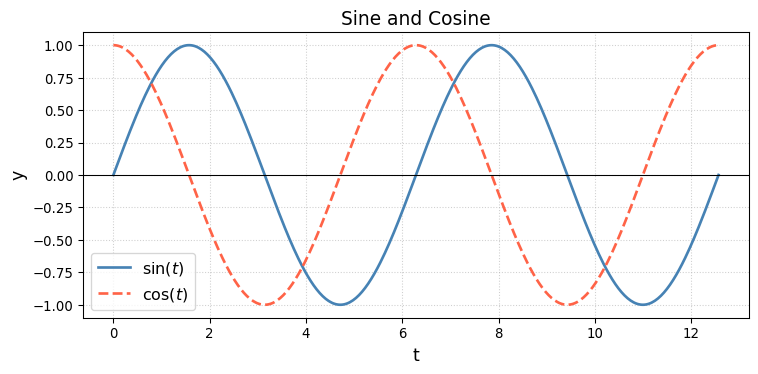

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data ---
t = np.linspace(0, 4 * np.pi, 400)   # 400 points from 0 to 4π

# --- Create figure and axes ---
fig, ax = plt.subplots(figsize=(8, 4))

# --- Plot curves ---
ax.plot(t, np.sin(t), label=r'$\sin(t)$', color='steelblue', linewidth=2)
ax.plot(t, np.cos(t), label=r'$\cos(t)$', color='tomato',    linewidth=2, linestyle='--')

# --- Labels and formatting ---
ax.set_xlabel('t', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('Sine and Cosine', fontsize=14)
ax.legend(fontsize=12)
ax.axhline(0, color='black', linewidth=0.8)  # draw y = 0 line
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Key ideas:**

- `fig, ax = plt.subplots()` creates a *figure* (the whole image) and an
  *axes* (the plotting region). This is the recommended, object-oriented
  style.
- `ax.plot(x, y)` draws a line.
- LaTeX math can be used in labels by wrapping strings with
  `r'$ ... $'`.
- `plt.tight_layout()` adjusts spacing to prevent clipped labels.

#### Plotting Multiple Subplots

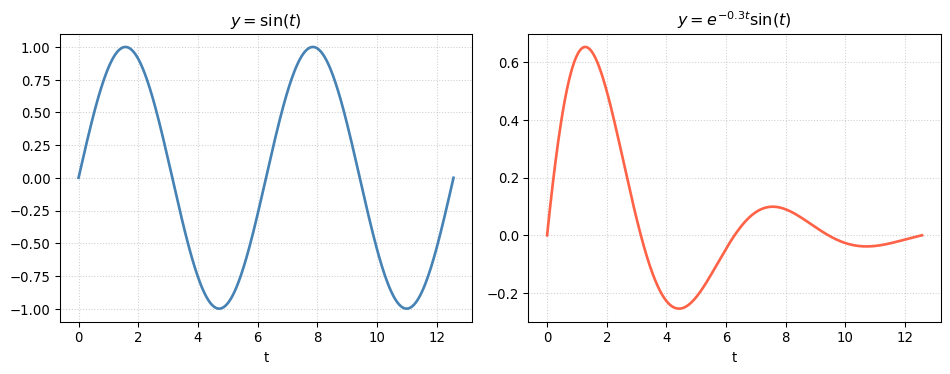

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))   # 1 row, 2 columns

t = np.linspace(0, 4*np.pi, 400)

axes[0].plot(t, np.sin(t), color='steelblue', linewidth=2)
axes[0].set_title(r'$y = \sin(t)$')
axes[0].set_xlabel('t')
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(t, np.exp(-0.3 * t) * np.sin(t), color='tomato', linewidth=2)
axes[1].set_title(r'$y = e^{-0.3t}\sin(t)$')
axes[1].set_xlabel('t')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### Saving Figures

``` python
fig.savefig("my_figure.png", dpi=150, bbox_inches="tight")
fig.savefig("my_figure.pdf")   # vector format; best for documents
```

### Plotting Vector Fields

In the study of differential equations, **direction fields** (also
called *slope fields* for first-order equations or *vector fields* for
systems) are invaluable for understanding qualitative behavior.

#### Slope Field for a First-Order ODE

For $\dfrac{dy}{dt} = f(t, y)$, we draw a short line segment at each
grid point $(t, y)$ with slope $f(t, y)$.

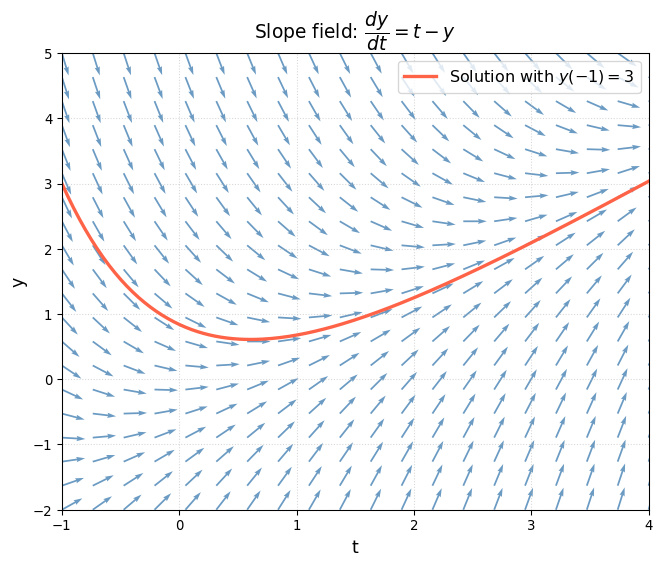

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ODE: dy/dt = t - y
def f(t, y):
    return t - y

# Create a grid of (t, y) values
t_vals = np.linspace(-1, 4, 20)
y_vals = np.linspace(-2, 5, 20)
T, Y = np.meshgrid(t_vals, y_vals)

# Compute slope at each grid point
dY = f(T, Y)
dT = np.ones_like(dY)            # dt component is always 1

# Normalize for uniform arrow length
magnitude = np.sqrt(dT**2 + dY**2)
dT_norm = dT / magnitude
dY_norm = dY / magnitude

fig, ax = plt.subplots(figsize=(7, 6))
ax.quiver(T, Y, dT_norm, dY_norm,
          angles='xy', color='steelblue', alpha=0.8, scale=25)

# Overlay a particular solution for reference
from scipy.integrate import solve_ivp
sol = solve_ivp(f, [-1, 4], [3.0], dense_output=True)
t_plot = np.linspace(-1, 4, 200)
ax.plot(t_plot, sol.sol(t_plot)[0], 'tomato', linewidth=2.5,
        label=r'Solution with $y(-1)=3$')

ax.set_xlabel('t', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title(r"Slope field: $\dfrac{dy}{dt} = t - y$", fontsize=14)
ax.legend(fontsize=12)
ax.set_xlim(-1, 4)
ax.set_ylim(-2, 5)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

#### Vector Field for a 2 × 2 System

For the system $\dfrac{d\mathbf{x}}{dt} = A\mathbf{x}$, we draw arrows
at each grid point $(x_1, x_2)$ pointing in the direction $(f_1, f_2)$.

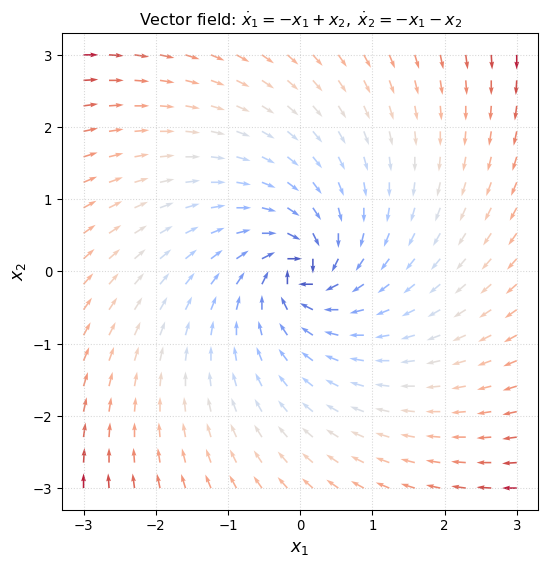

In [15]:
# System: dx/dt = -x + y,  dy/dt = -x - y
def system(X, Y):
    dX = -X + Y
    dY = -X - Y
    return dX, dY

x_vals = np.linspace(-3, 3, 18)
y_vals = np.linspace(-3, 3, 18)
X, Y = np.meshgrid(x_vals, y_vals)
dX, dY = system(X, Y)

mag = np.sqrt(dX**2 + dY**2)
dX_n = dX / mag
dY_n = dY / mag

fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(X, Y, dX_n, dY_n, mag, cmap='coolwarm', alpha=0.9)
ax.set_xlabel(r'$x_1$', fontsize=13)
ax.set_ylabel(r'$x_2$', fontsize=13)
ax.set_title(r"Vector field: $\dot{x}_1 = -x_1+x_2,\;\dot{x}_2 = -x_1-x_2$",
             fontsize=12)
ax.set_aspect('equal')
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

> **Tip**
>
> The `cmap='coolwarm'` coloring encodes the *speed* (magnitude) of the
> vector field — blue regions are slow, red regions are fast.

------------------------------------------------------------------------

## Intro to Scientific Python

### Intro to NumPy

[NumPy](https://numpy.org/doc/stable/) (Numerical Python) is the
foundation of scientific computing in Python (Harris et al. 2020). Its
central object is the **ndarray** — an efficient, multidimensional
array.

Full documentation: <https://numpy.org/doc/stable/>

#### Creating Arrays

In [16]:
import numpy as np

# From a Python list
a = np.array([1, 2, 3, 4, 5])
print(a)          # [1 2 3 4 5]
print(a.dtype)    # int64  (data type)
print(a.shape)    # (5,)   (dimensions)

# Floating-point array
b = np.array([1.0, 2.0, 3.0])
print(b.dtype)    # float64

# 2-D array (matrix)
A = np.array([[1, 2, 3],
              [4, 5, 6]])
print(A.shape)    # (2, 3)  → 2 rows, 3 columns

[1 2 3 4 5]
int64
(5,)
float64
(2, 3)

#### Useful Array-Creation Functions

In [17]:
print(np.zeros(4))           # [0. 0. 0. 0.]
print(np.ones((2, 3)))       # 2×3 matrix of ones
print(np.eye(3))             # 3×3 identity matrix
print(np.linspace(0, 1, 5)) # [0.   0.25 0.5  0.75 1.  ]
print(np.arange(0, 10, 2))  # [0 2 4 6 8]

[0. 0. 0. 0.]
[[1. 1. 1.]
 [1. 1. 1.]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[0.   0.25 0.5  0.75 1.  ]
[0 2 4 6 8]

#### Array Arithmetic

NumPy operations act **element-wise** by default:

In [18]:
a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 5.0, 6.0])

print(a + b)      # [5.  7.  9.]
print(a * b)      # [ 4. 10. 18.]  ← element-wise product
print(a ** 2)     # [1. 4. 9.]
print(np.sqrt(a)) # [1.    1.414 1.732]

[5. 7. 9.]
[ 4. 10. 18.]
[1. 4. 9.]
[1.         1.41421356 1.73205081]

> **Warning**
>
> `a * b` is **not** matrix multiplication. For matrix multiplication
> use `A @ B` or `np.dot(A, B)`.

In [19]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
print(A @ B)       # matrix product

[[19 22]
 [43 50]]

#### Universal Functions (ufuncs)

NumPy provides vectorized versions of all standard math functions:

In [20]:
t = np.linspace(0, np.pi, 5)
print(np.sin(t))
print(np.exp(-t))
print(np.log(t + 1))

[0.00000000e+00 7.07106781e-01 1.00000000e+00 7.07106781e-01
 1.22464680e-16]
[1.         0.45593813 0.20787958 0.09478022 0.04321392]
[0.         0.57964145 0.94421571 1.21080774 1.42108041]

These are far faster than looping over elements manually.

#### Array Indexing and Slicing

In [21]:
a = np.array([10, 20, 30, 40, 50])
print(a[0])     # 10  (first element)
print(a[-1])    # 50  (last element)
print(a[1:4])   # [20 30 40]  (slice: indices 1,2,3)
print(a[::2])   # [10 30 50]  (every other element)

# 2-D indexing
A = np.arange(12).reshape(3, 4)
print(A)
print(A[1, 2])    # element in row 1, column 2
print(A[:, 1])    # all rows, column 1  (column vector)
print(A[0, :])    # row 0

10
50
[20 30 40]
[10 30 50]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
6
[1 5 9]
[0 1 2 3]

------------------------------------------------------------------------

### Intro to SciPy

[SciPy](https://docs.scipy.org/doc/scipy/) builds on NumPy and provides
algorithms for optimization, integration, interpolation, signal
processing, statistics, and — most importantly for us — **differential
equations** (Virtanen et al. 2020).

Full documentation: <https://docs.scipy.org/doc/scipy/>

SciPy is organized into submodules:

| Submodule         | Content                            |
|-------------------|------------------------------------|
| `scipy.integrate` | Numerical integration, ODE solvers |
| `scipy.linalg`    | Linear algebra                     |
| `scipy.optimize`  | Root-finding, minimization         |
| `scipy.signal`    | Signal processing                  |
| `scipy.sparse`    | Sparse matrices                    |

Import submodules explicitly:

In [22]:
from scipy import integrate, linalg

SciPy’s ODE solvers and linear algebra routines are covered in the
dedicated sections below.

------------------------------------------------------------------------

### Intro to SymPy

[SymPy](https://docs.sympy.org/latest/) is a Python library for
**symbolic mathematics** — it performs exact algebraic manipulations
rather than numerical approximations (Meurer et al. 2017). Think of it
as a free, Python-native [computer algebra
system](https://en.wikipedia.org/wiki/Computer_algebra_system) (CAS).

Full documentation: <https://docs.sympy.org/latest/>

#### Symbols and Expressions

In [23]:
import sympy as sym

# Declare symbolic variables
t, y, C1, C2, k = sym.symbols('t y C1 C2 k', real=True)

# Build expressions
expr = sym.exp(-k * t) * sym.sin(t)
print(expr)

exp(-k*t)*sin(t)

#### Pretty Printing

In [24]:
sym.init_printing()   # enable pretty output in Jupyter/Quarto

expr2 = sym.sin(t)**2 + sym.cos(t)**2
print(sym.simplify(expr2))   # → 1

1

#### Calculus with SymPy

In [25]:
# Differentiation
f = sym.exp(-t) * sym.sin(2 * t)
df = sym.diff(f, t)
print("f'(t) =", df)

# Integration (indefinite)
integral = sym.integrate(f, t)
print("∫f dt =", integral)

# Definite integral
result = sym.integrate(sym.sin(t), (t, 0, sym.pi))
print("∫₀^π sin(t) dt =", result)   # 2

f'(t) = -exp(-t)*sin(2*t) + 2*exp(-t)*cos(2*t)
∫f dt = -exp(-t)*sin(2*t)/5 - 2*exp(-t)*cos(2*t)/5
∫₀^π sin(t) dt = 2

#### Solving Algebraic Equations

In [26]:
x = sym.Symbol('x')
solutions = sym.solve(x**2 - 5*x + 6, x)
print(solutions)   # [2, 3]

[2, 3]

#### Symbolic vs. Numerical

| Feature  | SymPy (symbolic)                   | NumPy/SciPy (numerical) |
|----------|------------------------------------|-------------------------|
| Results  | Exact                              | Approximate (float)     |
| Speed    | Slower                             | Faster                  |
| Good for | Deriving formulas, exact solutions | Large-scale computation |

You can convert a SymPy expression to a fast numerical function with
`sym.lambdify`:

In [27]:
f_sym = sym.sin(t) * sym.exp(-t)
f_num = sym.lambdify(t, f_sym, modules='numpy')  # converts to NumPy function
t_vals = np.linspace(0, 5, 200)
y_vals = f_num(t_vals)   # fast NumPy evaluation
print(y_vals[:5])

[0.         0.02449962 0.04776835 0.06983789 0.09073981]

------------------------------------------------------------------------

## Numerical Methods for ODEs in Python

### Using SciPy

[`scipy.integrate.solve_ivp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)
is the primary tool for solving initial value problems (IVPs)
numerically. It implements several
[Runge–Kutta](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods)
and [multi-step
methods](https://en.wikipedia.org/wiki/Linear_multistep_method).

**General call signature:**

``` python
solve_ivp(fun, t_span, y0, method='RK45', t_eval=None, ...)
```

| Argument | Meaning                                   |
|----------|-------------------------------------------|
| `fun`    | Function `f(t, y)` defining $y' = f(t,y)$ |
| `t_span` | `(t0, tf)` — start and end times          |
| `y0`     | Initial condition (list or array)         |
| `method` | ODE algorithm (default `'RK45'`)          |
| `t_eval` | Times at which to store the solution      |

#### Example 1: First-Order Linear ODE

Solve $y' = -2y$, $y(0) = 3$, and compare with the exact solution
$y(t) = 3e^{-2t}$.

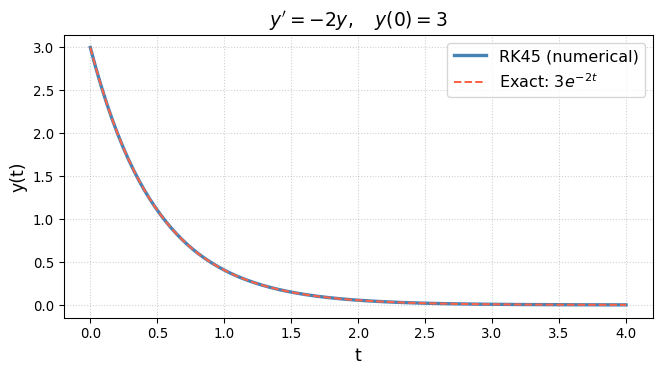

In [28]:
from scipy.integrate import solve_ivp

def ode(t, y):
    """dy/dt = -2*y"""
    return [-2 * y[0]]          # must return a list/array

t_span = (0, 4)
y0 = [3.0]                      # initial condition as a list
t_eval = np.linspace(0, 4, 200) # times at which to record solution

sol = solve_ivp(ode, t_span, y0, method='RK45', t_eval=t_eval)

# sol.t  → time values
# sol.y  → array of shape (n_variables, n_times)

# Exact solution for comparison
y_exact = 3 * np.exp(-2 * sol.t)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sol.t, sol.y[0], 'steelblue', linewidth=2.5, label='RK45 (numerical)')
ax.plot(sol.t, y_exact,  'tomato',    linewidth=1.5, linestyle='--',
        label=r'Exact: $3e^{-2t}$')
ax.set_xlabel('t', fontsize=13)
ax.set_ylabel('y(t)', fontsize=13)
ax.set_title(r"$y' = -2y,\quad y(0)=3$", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#### Example 2: Second-Order ODE (Mechanical Oscillator)

Solve the damped harmonic oscillator: $m x'' + c x' + k x = 0$.

We reduce to a first-order system: let $x_1 = x$, $x_2 = x'$. Then

$$x_1' = x_2, \qquad x_2' = -\frac{k}{m} x_1 - \frac{c}{m} x_2.$$

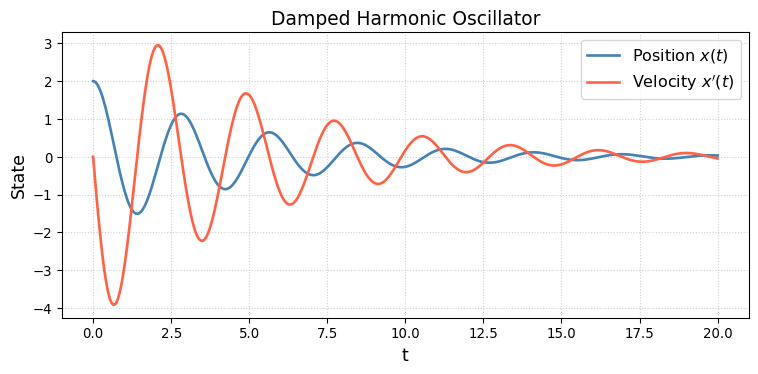

In [29]:
from scipy.integrate import solve_ivp

m = 1.0   # mass
c = 0.4   # damping coefficient
k = 5.0   # spring constant

def oscillator(t, state):
    """
    Damped harmonic oscillator as a first-order system.
    state = [x1, x2] = [position, velocity]
    """
    x1, x2 = state
    dx1 = x2
    dx2 = -(k/m) * x1 - (c/m) * x2
    return [dx1, dx2]

t_span = (0, 20)
y0     = [2.0, 0.0]         # initial position = 2, initial velocity = 0
t_eval = np.linspace(0, 20, 500)

sol = solve_ivp(oscillator, t_span, y0, method='RK45', t_eval=t_eval)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sol.t, sol.y[0], 'steelblue', linewidth=2, label='Position $x(t)$')
ax.plot(sol.t, sol.y[1], 'tomato',    linewidth=2, label='Velocity $x\'(t)$')
ax.set_xlabel('t', fontsize=13)
ax.set_ylabel('State', fontsize=13)
ax.set_title('Damped Harmonic Oscillator', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#### Example 3: Forced ODE

Solve $y'' + y = \cos(t)$ (resonance) with $y(0) = 0$, $y'(0) = 0$.

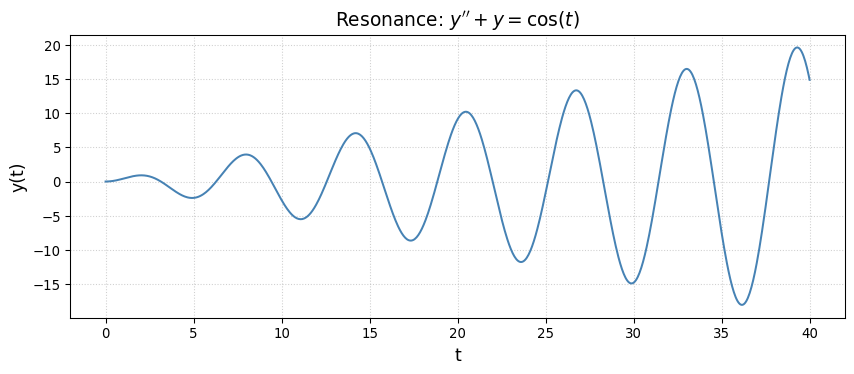

In [30]:
from scipy.integrate import solve_ivp

def forced_oscillator(t, state):
    x1, x2 = state
    dx1 = x2
    dx2 = -x1 + np.cos(t)   # forcing term cos(t) at natural frequency
    return [dx1, dx2]

t_span = (0, 40)
y0     = [0.0, 0.0]
t_eval = np.linspace(0, 40, 800)

sol = solve_ivp(forced_oscillator, t_span, y0, method='RK45', t_eval=t_eval,
                rtol=1e-8, atol=1e-10)   # tighter tolerances for accuracy

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sol.t, sol.y[0], 'steelblue', linewidth=1.5)
ax.set_xlabel('t', fontsize=13)
ax.set_ylabel('y(t)', fontsize=13)
ax.set_title(r"Resonance: $y'' + y = \cos(t)$", fontsize=14)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#### Available ODE Methods in `solve_ivp`

| `method`   | Description                                       |
|------------|---------------------------------------------------|
| `'RK45'`   | Runge–Kutta 4(5); default; good for most problems |
| `'RK23'`   | Runge–Kutta 2(3); lower accuracy, faster          |
| `'DOP853'` | Dormand–Prince 8(5,3); high accuracy              |
| `'Radau'`  | Implicit Runge–Kutta; best for stiff problems     |
| `'BDF'`    | Backward differentiation formula; stiff problems  |
| `'LSODA'`  | Automatically detects stiffness                   |

In [31]:
# Accessing the solution object
print("Success?", sol.success)
print("Message:", sol.message)
print("Solution shape (n_vars × n_times):", sol.y.shape)

Success? True
Message: The solver successfully reached the end of the integration interval.
Solution shape (n_vars × n_times): (2, 800)

------------------------------------------------------------------------

### Using SymPy

SymPy can find **exact, closed-form solutions** to ODEs when they exist.

In [32]:
import sympy as sym

t = sym.Symbol('t')
y = sym.Function('y')   # y is a function of t

#### Example 1: First-Order Linear ODE

Solve $y' + 2y = 4$, $y(0) = 1$.

In [33]:
ode_eq = sym.Eq(y(t).diff(t) + 2*y(t), 4)
general = sym.dsolve(ode_eq, y(t))
print("General solution:", general)

# Apply initial condition y(0) = 1
C1 = sym.Symbol('C1')
ic  = {C1: sym.solve(general.rhs.subs(t, 0) - 1, C1)[0]}
particular = general.subs(ic)
print("Particular solution:", particular)

General solution: Eq(y(t), C1*exp(-2*t) + 2)
Particular solution: Eq(y(t), 2 - exp(-2*t))

#### Example 2: Second-Order ODE

Solve $y'' - 3y' + 2y = 0$, $y(0) = 0$, $y'(0) = 1$.

In [34]:
ode2 = sym.Eq(y(t).diff(t,2) - 3*y(t).diff(t) + 2*y(t), 0)
general2 = sym.dsolve(ode2, y(t))
print("General solution:", general2)

C1, C2 = sym.symbols('C1 C2')
ics = sym.solve([
    general2.rhs.subs(t, 0) - 0,          # y(0) = 0
    general2.rhs.diff(t).subs(t, 0) - 1   # y'(0) = 1
], [C1, C2])
particular2 = general2.subs(ics)
print("Particular solution:", particular2)

General solution: Eq(y(t), (C1 + C2*exp(t))*exp(t))
Particular solution: Eq(y(t), (exp(t) - 1)*exp(t))

#### Example 3: Nonhomogeneous ODE

Solve $y'' + y = \sin(t)$ (the resonance equation) symbolically.

In [35]:
ode3 = sym.Eq(y(t).diff(t,2) + y(t), sym.sin(t))
general3 = sym.dsolve(ode3, y(t))
print(general3)

Eq(y(t), C2*sin(t) + (C1 - t/2)*cos(t))

------------------------------------------------------------------------

## Linear Algebra in Python

### Numerical Linear Algebra with NumPy and SciPy

#### Matrices and Vectors

In [36]:
import numpy as np

A = np.array([[2, 1],
              [5, 3]], dtype=float)

b = np.array([4, 7], dtype=float)

print("Matrix A:\n", A)
print("Vector b:", b)

Matrix A:
 [[2. 1.]
 [5. 3.]]
Vector b: [4. 7.]

#### Solving Linear Systems $Ax = b$

In [37]:
from scipy import linalg

x = linalg.solve(A, b)
print("Solution x:", x)

# Verify: A @ x should equal b
print("Residual A @ x - b:", A @ x - b)

Solution x: [ 5. -6.]
Residual A @ x - b: [0.00000000e+00 3.55271368e-15]

#### Matrix Operations

In [38]:
# Transpose
print("A^T:\n", A.T)

# Determinant
print("det(A):", linalg.det(A))

# Inverse
print("A^{-1}:\n", linalg.inv(A))

# Matrix–vector product
print("A @ x:", A @ x)

# Matrix–matrix product
B = np.array([[1, 0], [0, 2]], dtype=float)
print("A @ B:\n", A @ B)

A^T:
 [[2. 5.]
 [1. 3.]]
det(A): 1.0
A^{-1}:
 [[ 3. -1.]
 [-5.  2.]]
A @ x: [4. 7.]
A @ B:
 [[2. 2.]
 [5. 6.]]

#### Computing Eigenvalues and Eigenvectors with NumPy and SciPy

For a square matrix $A$, the eigenvalue problem is
$A\mathbf{v} = \lambda \mathbf{v}$.

In [39]:
import numpy as np
from scipy import linalg

A = np.array([[4, 1],
              [2, 3]], dtype=float)

# Using NumPy (returns unsorted eigenvalues)
eigenvalues, eigenvectors = np.linalg.eig(A)
print("Eigenvalues (NumPy):", eigenvalues)
print("Eigenvectors (columns):\n", eigenvectors)

Eigenvalues (NumPy): [5. 2.]
Eigenvectors (columns):
 [[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

In [40]:
# Using SciPy (more options; can return left eigenvectors, etc.)
vals, vecs = linalg.eig(A)
print("Eigenvalues (SciPy):", vals.real)

# The j-th eigenvector is vecs[:, j]
for j in range(len(vals)):
    lam = vals[j].real
    v   = vecs[:, j].real
    print(f"  λ = {lam:.4f},  v = {v}")
    print(f"  Verify A @ v = λ * v: {np.allclose(A @ v, lam * v)}")

Eigenvalues (SciPy): [5. 2.]
  λ = 5.0000,  v = [0.70710678 0.70710678]
  Verify A @ v = λ * v: True
  λ = 2.0000,  v = [-0.4472136   0.89442719]
  Verify A @ v = λ * v: True

> **Note**
>
> `np.linalg.eig` and `scipy.linalg.eig` may return complex eigenvalues
> even for real matrices (when complex eigenvalues occur in conjugate
> pairs). Use `.real` and `.imag` to extract real and imaginary parts.

In [41]:
# Symmetric matrices: use eigh for guaranteed real, sorted eigenvalues
C = np.array([[3, 1], [1, 2]], dtype=float)
vals_sym, vecs_sym = np.linalg.eigh(C)
print("Eigenvalues of symmetric matrix:", vals_sym)

Eigenvalues of symmetric matrix: [1.38196601 3.61803399]

------------------------------------------------------------------------

### Symbolic Linear Algebra with SymPy

In [42]:
import sympy as sym

A = sym.Matrix([[4, 1],
                [2, 3]])

print("Matrix A:")
sym.pprint(A)

# Determinant and inverse
print("\ndet(A) =", A.det())
print("\nA^{-1}:")
sym.pprint(A.inv())

Matrix A:
⎡4  1⎤
⎢    ⎥
⎣2  3⎦

det(A) = 10

A^{-1}:
⎡3/10  -1/10⎤
⎢           ⎥
⎣-1/5   2/5 ⎦

#### Solving Linear Systems Symbolically

In [43]:
b = sym.Matrix([5, 4])
x = A.solve(b)
print("Solution x:", x.T)

Solution x: Matrix([[11/10, 3/5]])

#### Computing Eigenvalues and Eigenvectors with SymPy

In [44]:
# eigenvals() returns {eigenvalue: algebraic_multiplicity, ...}
evals = A.eigenvals()
print("Eigenvalues:", evals)

# eigenvects() returns [(eigenvalue, multiplicity, [eigenvectors]), ...]
evects = A.eigenvects()
for lam, mult, vecs in evects:
    print(f"\nλ = {lam}  (multiplicity {mult})")
    for v in vecs:
        print(f"  eigenvector: {v.T}")

Eigenvalues: {5: 1, 2: 1}

λ = 2  (multiplicity 1)
  eigenvector: Matrix([[-1/2, 1]])

λ = 5  (multiplicity 1)
  eigenvector: Matrix([[1, 1]])

In [45]:
# Diagonalization: A = P * D * P^{-1}
P, D = A.diagonalize()
print("P ="); sym.pprint(P)
print("D ="); sym.pprint(D)
print("P * D * P^{-1} ="); sym.pprint(sym.simplify(P * D * P.inv()))

P =
⎡-1  1⎤
⎢     ⎥
⎣2   1⎦
D =
⎡2  0⎤
⎢    ⎥
⎣0  5⎦
P * D * P^{-1} =
⎡4  1⎤
⎢    ⎥
⎣2  3⎦

In [46]:
# Symbolic matrix with a parameter
a = sym.Symbol('a')
B = sym.Matrix([[a, 1], [1, a]])
print("Eigenvalues of [[a,1],[1,a]]:", B.eigenvals())

Eigenvalues of [[a,1],[1,a]]: {a - 1: 1, a + 1: 1}

------------------------------------------------------------------------

## Phase Portraits in Python

A **phase portrait** shows the trajectories of a two-dimensional
autonomous system
$$\frac{d\mathbf{x}}{dt} = \mathbf{f}(\mathbf{x}), \qquad \mathbf{x} = (x_1, x_2)^T,$$
in the $(x_1, x_2)$ plane (the *phase plane*) for many different initial
conditions.

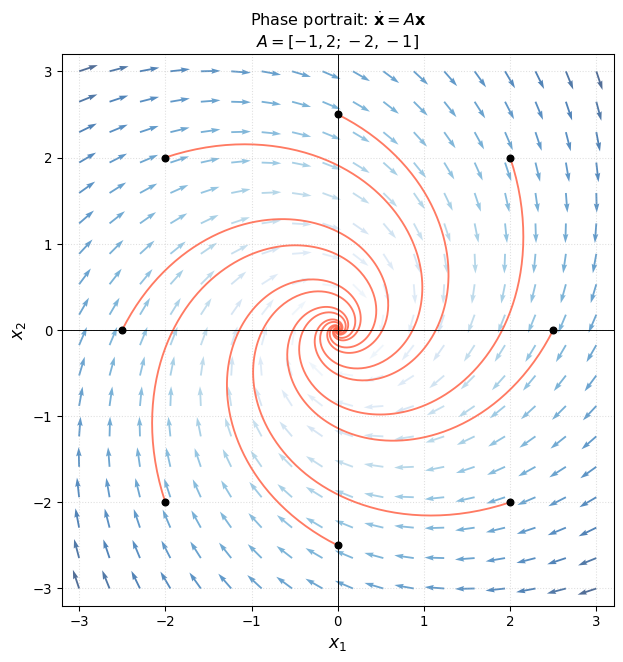

In [47]:
from scipy.integrate import solve_ivp

def linear_system(t, state, A):
    """Linear system dx/dt = A*x."""
    return A @ np.array(state)

# System matrix
A_mat = np.array([[-1, 2],
                  [-2, -1]], dtype=float)

# Grid for the vector field
x1 = np.linspace(-3, 3, 18)
x2 = np.linspace(-3, 3, 18)
X1, X2 = np.meshgrid(x1, x2)
dX1 = A_mat[0, 0]*X1 + A_mat[0, 1]*X2
dX2 = A_mat[1, 0]*X1 + A_mat[1, 1]*X2
mag = np.sqrt(dX1**2 + dX2**2)

fig, ax = plt.subplots(figsize=(7, 7))

# Plot the vector field
ax.quiver(X1, X2, dX1/mag, dX2/mag, mag,
          cmap='Blues', alpha=0.7, scale=28)

# Plot several trajectories from different initial conditions
initial_conditions = [
    [2.5, 0], [-2.5, 0], [0, 2.5], [0, -2.5],
    [2, 2],   [-2, -2],  [2, -2],  [-2, 2]
]

t_span = (0, 6)
t_eval = np.linspace(0, 6, 300)

for ic in initial_conditions:
    sol = solve_ivp(linear_system, t_span, ic, args=(A_mat,),
                    t_eval=t_eval, method='RK45')
    ax.plot(sol.y[0], sol.y[1], 'tomato', linewidth=1.4, alpha=0.85)
    # Mark starting point
    ax.plot(ic[0], ic[1], 'ko', markersize=5)

ax.set_xlabel(r'$x_1$', fontsize=13)
ax.set_ylabel(r'$x_2$', fontsize=13)
ax.set_title(
    r'Phase portrait: $\dot{\mathbf{x}} = A\mathbf{x}$' +
    f'\n$A = [{A_mat[0,0]:.0f},{A_mat[0,1]:.0f};{A_mat[1,0]:.0f},{A_mat[1,1]:.0f}]$',
    fontsize=12
)
ax.axhline(0, color='k', linewidth=0.7)
ax.axvline(0, color='k', linewidth=0.7)
ax.set_aspect('equal')
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-3.2, 3.2)
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

#### Nonlinear System: Pendulum

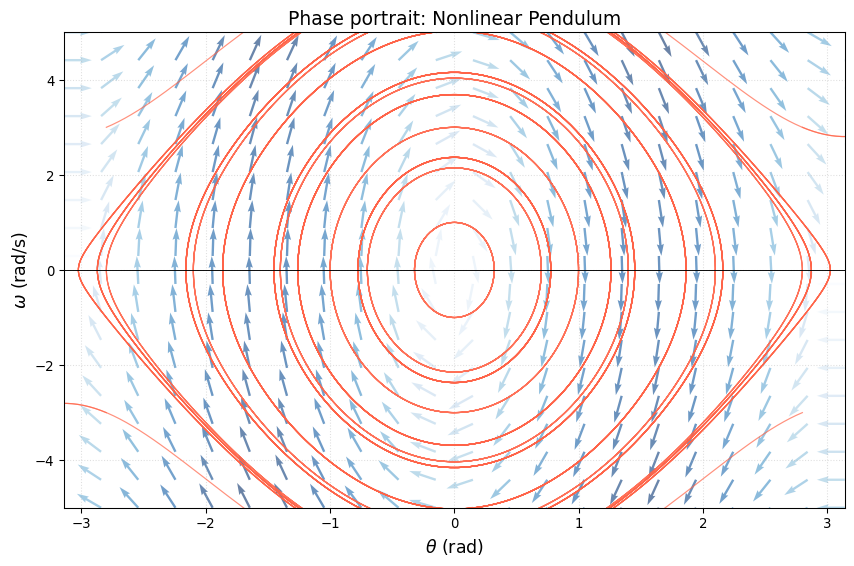

In [48]:
from scipy.integrate import solve_ivp

g = 9.8   # gravitational acceleration (m/s²)
L = 1.0   # pendulum length (m)

def pendulum(t, state):
    """
    Nonlinear pendulum (no damping).
    state = [theta, omega]  (angle, angular velocity)
    """
    theta, omega = state
    return [omega, -(g/L) * np.sin(theta)]

x1 = np.linspace(-np.pi, np.pi, 22)
x2 = np.linspace(-5, 5, 18)
X1, X2 = np.meshgrid(x1, x2)
dX1 = X2
dX2 = -(g/L) * np.sin(X1)
mag = np.sqrt(dX1**2 + dX2**2)

fig, ax = plt.subplots(figsize=(9, 6))
ax.quiver(X1, X2, dX1/mag, dX2/mag, mag, cmap='Blues', alpha=0.6, scale=28)

for theta0 in np.linspace(-2.8, 2.8, 9):
    for omega0 in [-3, -1, 0, 1, 3]:
        sol = solve_ivp(pendulum, (0, 8), [theta0, omega0],
                        t_eval=np.linspace(0, 8, 500), method='RK45',
                        rtol=1e-8, atol=1e-10)
        ax.plot(sol.y[0], sol.y[1], 'tomato', linewidth=0.9, alpha=0.7)

ax.set_xlabel(r'$\theta$ (rad)', fontsize=13)
ax.set_ylabel(r'$\omega$ (rad/s)', fontsize=13)
ax.set_title('Phase portrait: Nonlinear Pendulum', fontsize=14)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-5, 5)
ax.axhline(0, color='k', linewidth=0.7)
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

------------------------------------------------------------------------

## Laplace Transforms with SymPy

The [Laplace transform](https://en.wikipedia.org/wiki/Laplace_transform)
$\mathcal{L}\{f(t)\}$ is an important tool for solving linear ODEs with
constant coefficients. SymPy can compute Laplace transforms and inverse
Laplace transforms symbolically.

In [49]:
import sympy as sym

t, s = sym.symbols('t s', positive=True)

# Forward Laplace transform
f = sym.exp(-2*t) * sym.sin(3*t)
F = sym.laplace_transform(f, t, s, noconds=True)
print("L{e^{-2t} sin(3t)} =", F)

L{e^{-2t} sin(3t)} = 3/((s + 2)**2 + 9)

In [50]:
# Inverse Laplace transform
G = s / (s**2 + 4)
g = sym.inverse_laplace_transform(G, s, t)
print("L^{-1}{s/(s²+4)} =", g)

L^{-1}{s/(s²+4)} = cos(2*t)

In [51]:
# Solving an IVP via Laplace transform
# Solve y'' + 4y = 0, y(0) = 1, y'(0) = 0

Y = sym.Function('Y')   # Y(s) = L{y(t)}

# Using known Laplace transform rules:
# L{y''} = s^2*Y - s*y(0) - y'(0)
#         = s^2*Y - s - 0
# So: (s^2 + 4)*Y = s  =>  Y = s/(s^2 + 4)
Y_s = s / (s**2 + 4)
y_t = sym.inverse_laplace_transform(Y_s, s, t)
print("Solution y(t) =", y_t)   # cos(2t)

Solution y(t) = cos(2*t)

------------------------------------------------------------------------

## Tips for Debugging Python Code

Even experienced programmers spend much of their time debugging. Here
are some practical strategies.

### Read the Error Message

Python’s error messages are informative. The last line tells you the
error type and a short description; the lines above show the *traceback*
— where in the code the error occurred.

``` python
# Common error types
# NameError    — you used a variable or function that isn't defined
# TypeError    — wrong type passed to a function
# ValueError   — right type, but inappropriate value
# IndexError   — index out of bounds
# ZeroDivisionError — division by zero
# AttributeError — object doesn't have the attribute/method you called
```

### Use `print` Statements

Insert `print()` calls to inspect intermediate values:

``` python
def my_ode(t, y):
    result = -2 * y[0]
    print(f"t={t:.3f}, y={y[0]:.6f}, f={result:.6f}")  # debug line
    return [result]
```

### Check Array Shapes

Shape mismatches are a common source of errors in NumPy code:

``` python
print(A.shape)   # always check shapes when something looks wrong
print(b.shape)
```

### Useful Resources

- [Official Python Docs](https://docs.python.org/3/)
- [Stack Overflow](https://stackoverflow.com/) — searching your exact
  error message often finds an answer immediately
- [NumPy Debugging
  Guide](https://numpy.org/doc/stable/user/quickstart.html)

------------------------------------------------------------------------

## References

Harris, Charles R., K. Jarrod Millman, Stéfan J. van der Walt, et al.
2020. “Array Programming with NumPy.” *Nature* 585: 357–62.
<https://doi.org/10.1038/s41586-020-2649-2>.

Hunter, John D. 2007. “Matplotlib: A 2D Graphics Environment.”
*Computing in Science & Engineering* 9 (3): 90–95.
<https://doi.org/10.1109/MCSE.2007.55>.

Meurer, Aaron, Christopher P. Smith, Mateusz Paprocki, et al. 2017.
“SymPy: Symbolic Computing in Python.” *PeerJ Computer Science* 3: e103.
<https://doi.org/10.7717/peerj-cs.103>.

Python Software Foundation. 2024. *Python Language Reference, Version
3*. <https://docs.python.org/3/>.

Virtanen, Pauli, Ralf Gommers, Travis E. Oliphant, et al. 2020. “SciPy
1.0: Fundamental Algorithms for Scientific Computing in Python.” *Nature
Methods* 17: 261–72. <https://doi.org/10.1038/s41592-019-0686-2>.

> **Expand for Session Info**
>
> ``` python
> import sys
> print("Python version:", sys.version)
> print('\n'.join(f'{m.__name__}=={m.__version__}' for m in globals().values() if getattr(m, '__version__', None)))
> ```
>
>     Python version: 3.14.4 | packaged by conda-forge | (main, Apr  8 2026, 02:33:53) [Clang 20.1.8 ]
>     numpy==2.4.3
>     scipy==1.17.1
>     sympy==1.14.0
>     matplotlib==3.10.8

## Reuse

[![](http://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc-sa.png?raw=1)](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode)

[CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/)